# 07. Self-Organizing Map (SOM)
**Algorithm implemented:** Kohonen Self-Organizing Map (via MiniSom).

**Dataset:** UCI Wine (178 samples, 13 chemical features, 3 cultivars used only for visualization).


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Dataset + scaling ----
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler
# ---- MiniSom: lightweight Kohonen Self-Organizing Map implementation ----
from minisom import MiniSom

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print("MiniSom and libraries loaded successfully!")

# ---- Load the Wine recognition dataset ----
wine = load_wine()
X_raw = wine.data          # 178 samples x 13 chemical features
y = wine.target            # 3 wine cultivars (only used for visualization - SOM is unsupervised)
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Samples: {X_raw.shape[0]}, Features: {X_raw.shape[1]}, Classes: {target_names.tolist()}")

# ---- MinMax scaling to [0, 1] ----
# SOM weight vectors live in the same range as the inputs, so scaling keeps learning stable.
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)


MiniSom and libraries loaded successfully!
Samples: 178, Features: 13, Classes: ['class_0', 'class_1', 'class_2']


## Kohonen SOM

### Step-by-Step Algorithm (Kohonen Self-Organizing Map)
1. **Initialize** an M x N grid of neurons, each with a random weight vector w_j of the same dimension as the input.
2. **Sample** a training input x (randomly, with replacement).
3. **Competitive phase:** find the Best Matching Unit (BMU) c = argmin_j ||x − w_j||.
4. **Cooperative phase:** compute the Gaussian neighborhood kernel h_cj = exp(−||r_c − r_j||² / (2σ(t)²)).
5. **Adaptive phase:** move the BMU and its neighbors toward x: w_j ← w_j + α(t) h_cj (x − w_j).
6. **Decay** the learning rate α(t) and neighborhood radius σ(t) after each step.
7. **Repeat** steps 2-6 for many iterations until the map stabilizes.
8. **Output:** a 2D topology-preserving map; each sample is assigned to the neuron (BMU) closest to it.

### How the U-Matrix Is Built
1. Train the SOM until the weight vectors organize.
2. For every neuron compute the average Euclidean distance to its immediate grid neighbors.
3. Render these averages as a heatmap: bright ridges separate clusters, dark valleys are cluster interiors.
4. Project each sample onto its BMU using the marker of its true cultivar to check unsupervised separation.

In [2]:
# ---- Configure the Kohonen grid ----
grid_x, grid_y = 12, 12  # 12x12 grid = 144 neurons (fewer than the 178 samples)
input_len = X.shape[1]   # 13 chemical features per neuron weight vector

som = MiniSom(
    x=grid_x,
    y=grid_y,
    input_len=input_len,
    sigma=1.5,                       # initial neighborhood radius
    learning_rate=0.5,               # initial learning rate
    neighborhood_function='gaussian',# smooth Gaussian neighborhood kernel
    random_seed=42
)

# ---- Initialize weights with PCA for topologically faithful, faster convergence ----
som.pca_weights_init(X)
print("Initial Quantization Error:", som.quantization_error(X))

# ---- Train: 5000 random samples presented to the map ----
som.train_random(data=X, num_iteration=5000, verbose=False)
final_qe = som.quantization_error(X)   # average distance from samples to their BMU
final_te = som.topographic_error(X)    # fraction of samples whose 2nd BMU is not a grid neighbor

print(f"Training complete after 5,000 iterations!")
print(f" - Final Quantization Error (mean distance to BMU): {final_qe:.4f}")
print(f" - Final Topographic Error (proportion of foldings): {final_te:.4f}")


Initial Quantization Error: 0.4447391189659704


Training complete after 5,000 iterations!
 - Final Quantization Error (mean distance to BMU): 0.1965
 - Final Topographic Error (proportion of foldings): 0.0393


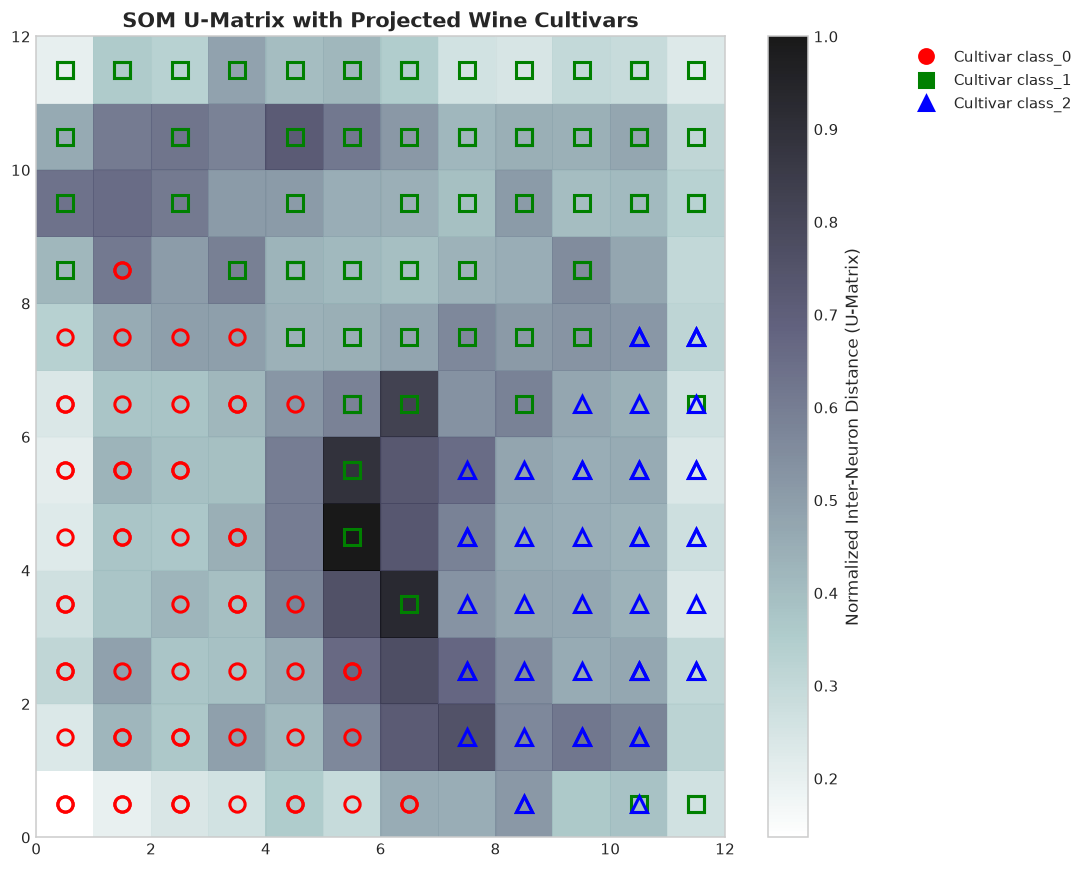

In [3]:
# ---- Plot the U-Matrix (unified distance map) ----
# Each cell = average distance between a neuron and its immediate grid neighbors.
# Dark valleys = dense clusters; bright ridges = boundaries between clusters.
plt.figure(figsize=(10, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r', alpha=0.9)
cbar = plt.colorbar()
cbar.set_label("Normalized Inter-Neuron Distance (U-Matrix)", fontsize=11)

# ---- Project every sample onto its Best Matching Unit (BMU) ----
markers = ['o', 's', '^']
colors = ['red', 'green', 'blue']

for idx, x_vec in enumerate(X):
    w = som.winner(x_vec)  # grid coordinates of the best matching neuron for this sample
    plt.plot(
        w[0] + 0.5,        # +0.5 centers the marker inside the pcolor cell
        w[1] + 0.5,
        markers[y[idx]],   # marker shape encodes the true cultivar
        markerfacecolor='None',
        markeredgecolor=colors[y[idx]],
        markersize=10,
        markeredgewidth=2
    )

# Build a legend for the three cultivars
for c_idx, c_name in enumerate(target_names):
    plt.plot([], [], marker=markers[c_idx], color=colors[c_idx], linestyle='None',
             label=f'Cultivar {c_name}', markersize=9, markeredgewidth=2)

plt.title("SOM U-Matrix with Projected Wine Cultivars", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.25, 1), loc='upper left')
plt.tight_layout()
plt.show()
